# Prophet Meta
**Equipo:** Alejandro Riveros, Manuel Carreño y Carlos Diaz

## 0. Carga de Librerias

In [1]:
# Instalacion (ejecutar solo si no estan instaladas)
# !pip install prophet pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

print('Librerias cargadas correctamente')

c:\Users\manue\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Librerias cargadas correctamente


---
## 1. Indice

1. Indice
2. Que es Prophet?
3. Componentes
4. Como funciona Prophet?
5. Parametros
6. Implementacion en Python
7. Personalizacion de parametros
8. Evaluacion (metricas), ventajas y desventajas
9. Conclusiones

---
## 2. Que es Prophet?

Prophet es una libreria de **codigo abierto** desarrollada por el equipo de Core Data Science de **Meta** (antes Facebook) para realizar pronosticos de series de tiempo. Fue creada por Sean J. Taylor y Ben Letham, y publicada en 2017 para Python y R.

El objetivo de Prophet es **democratizar el pronostico**: permitir que tanto expertos en estadistica como usuarios sin conocimientos avanzados puedan generar predicciones confiables con pocos pasos. Esto lo diferencia de metodos como ARIMA o SARIMA, que requieren configuracion manual compleja.

**Caracteristicas principales:**

| Caracteristica | Descripcion |
|---|---|
| Codigo abierto | Disponible en PyPI (Python) y CRAN (R) |
| Robusto | Maneja valores faltantes, cambios bruscos en la tendencia y outliers |
| Rapido | Usa Stan internamente, logrando pronosticos en pocos segundos |
| Interpretable | Cada componente tiene un significado claro, no es una caja negra |
| Facil de usar | Solo requiere columnas `ds` (fecha) e `y` (valor a predecir) |
| Escalable | Disenado para trabajar con miles de series de tiempo simultaneamente |

**Aplicaciones comunes:**

- Pronostico de ventas y demanda en e-commerce y retail.
- Analisis financiero: prediccion de ingresos, precios de acciones y tipos de cambio.
- Prediccion de trafico web y consumo de energia.
- Planificacion de campanas de marketing con festivos y eventos especiales.

---
## 3. Componentes del Modelo Prophet

### 3.1 Tendencia — g(t)

Captura el **comportamiento general a largo plazo** ignorando los altibajos del dia a dia.

**Analogia:** Es como observar el precio de una casa durante 10 anos. Puede subir en general aunque haya meses donde baje un poco.

Prophet ofrece dos tipos de tendencia:

**Tipo 1 - Lineal por tramos (el mas comun)**

Para datos sin un limite maximo. Detecta automaticamente puntos donde la tendencia cambia de velocidad. Estos se llaman **changepoints**.

**Tipo 2 - Logistico**

Para datos con un techo maximo conocido (ej: usuarios de una app en un mercado de 10 millones de personas, nunca puede superar ese numero).

> **Parametro clave:** `changepoint_prior_scale` controla la flexibilidad de la tendencia (valor por defecto = 0.05).

### 3.2 Estacionalidad — s(t)

Captura **patrones que se repiten periodicamente**.

**Analogia:** Las ventas de paraguas siempre suben en invierno. Las visitas a un sitio de noticias siempre suben los lunes. Esos son patrones estacionales.

Prophet detecta automaticamente tres tipos:

| Tipo | Cuando aplica | Ejemplo |
|---|---|---|
| **Anual** | Datos de meses o años | Ventas navidenas, temporadas |
| **Semanal** | Datos de dias | Mas trafico los lunes que los sabados |
| **Diaria** | Datos de horas | Mas llamadas al mediodia que a las 3am |

Tambien se pueden agregar estacionalidades personalizadas con `add_seasonality()`.

### 3.3 Festivos y Eventos — h(t)

Captura **dias especiales que rompen el patron normal** y que el modelo no puede detectar por si solo.

**Analogia:** El Black Friday siempre dispara las ventas. El 25 de diciembre las visitas caen a cero. Si no le avisas al modelo, lo vera como un error extrano en los datos.

Con Prophet puedes:
- Agregar festivos de tu pais: `modelo.add_country_holidays(country_name='CO')`
- Definir eventos propios (lanzamientos, campanas de marketing)
- Especificar ventanas de impacto: cuantos dias antes y despues tambien se ven afectados

> Prophet ya tiene festivos predefinidos para Colombia, Mexico, Espana, EE.UU. y mas.

---
## 4. Como funciona Prophet?

Prophet divide una serie de tiempo en **partes separadas** y las suma para generar el pronostico final. En lugar de ver los datos como un bloque confuso, los descompone en capas con un significado claro:

**y(t) = g(t) + s(t) + h(t) + ε(t)**

> **Analogia:** Imagina que quieres entender cuanto gana un vendedor en un dia. Puedes separarlo en: su sueldo base (tendencia) + bono por temporada alta (estacionalidad) + comision por dia festivo (holidays) + lo impredecible del dia (error). La suma de esas partes da el total. Eso es exactamente lo que hace Prophet con los datos.

| Componente | Representa | Ejemplo |
|---|---|---|
| g(t) | **Tendencia:** direccion general a largo plazo | Ventas que crecen ano tras ano |
| s(t) | **Estacionalidad:** patrones que se repiten | Picos cada diciembre |
| h(t) | **Festivos:** dias especiales que rompen el patron normal | Black Friday, Navidad |
| ε(t) | **Error:** lo que el modelo no logra explicar | Variaciones impredecibles |

A diferencia de ARIMA, Prophet trata el pronostico como un **ajuste de curvas**, lo que le da flexibilidad, velocidad e interpretabilidad.

**Proceso interno paso a paso:**

1. **Recibe los datos** con columnas  (fecha) e  (valor a predecir).
2. **Identifica la tendencia** y detecta automaticamente los **changepoints**: momentos donde la tendencia cambia de direccion (ej: cuando las ventas empezaron a bajar tras un pico).
3. **Detecta los patrones repetitivos** (estacionalidad). Para esto combina ondas matematicas simples hasta aproximar el patron real. El modelo decide solo cuantas necesita — el usuario no tiene que configurar nada.
4. **Incorpora festivos y eventos especiales** como informacion adicional, para que el modelo no los confunda con errores o anomalias.
5. **Calcula los mejores valores** para cada componente usando un motor de optimizacion interno. Este proceso es completamente automatico y ocurre en segundos.
6. **Genera el pronostico** con un valor predicho () y un rango de incertidumbre (, ).

---
## 5. Parametros de Prophet

Al crear el modelo se pueden configurar distintos parametros. A continuacion se describen los principales, agrupados por categoria.

**Tendencia:**

| Parametro | Que controla | Valor por defecto |
|---|---|---|
| `growth` | Forma en que crece la tendencia: `linear` (sin limite), `logistic` (con techo maximo definido) o `flat` (sin tendencia) | `linear` |
| `n_changepoints` | Cuantos puntos de cambio potenciales evalua el modelo en el historial | 25 |
| `changepoint_range` | Hasta que proporcion del historial busca changepoints (0.8 = en el 80% inicial) | 0.8 |
| `changepoint_prior_scale` | Que tan flexible es la tendencia. **Bajo (0.01-0.05):** tendencia rigida. **Alto (0.3-0.5):** tendencia muy flexible, puede seguir el ruido | 0.05 |

**Estacionalidad:**

| Parametro | Que controla | Valor por defecto |
|---|---|---|
| `yearly_seasonality` | Activa o desactiva el patron anual. `True`, `False` o `auto` (Prophet decide segun la cantidad de datos) | `auto` |
| `weekly_seasonality` | Activa o desactiva el patron semanal | `auto` |
| `daily_seasonality` | Activa o desactiva el patron diario. Solo util con datos por hora | `auto` |
| `seasonality_mode` | `additive`: el efecto estacional es fijo sin importar el nivel de los datos. `multiplicative`: el efecto crece proporcionalmente al nivel de los datos | `additive` |
| `seasonality_prior_scale` | Que tan marcados pueden ser los patrones estacionales. Subir este valor permite que el modelo capture variaciones estacionales mas grandes | 10.0 |

**Festivos:**

| Parametro | Que controla | Valor por defecto |
|---|---|---|
| `holidays` | DataFrame con festivos personalizados. Debe tener columnas `holiday` (nombre) y `ds` (fecha) | `None` |
| `holidays_prior_scale` | Que tan grande puede ser el impacto de un festivo en la prediccion. Subir este valor le da mas peso a los dias festivos | 10.0 |

**Incertidumbre:**

| Parametro | Que controla | Valor por defecto |
|---|---|---|
| `interval_width` | Ancho del intervalo de confianza. 0.80 significa que el 80% de los valores reales deberian caer dentro de la banda | 0.80 |
| `uncertainty_samples` | Numero de simulaciones internas para calcular el intervalo de incertidumbre. Mas muestras = banda mas precisa pero mas lento | 1000 |
| `mcmc_samples` | Con 0 el calculo de incertidumbre es rapido (solo sobre la tendencia). Con valores mayores el calculo es mas completo pero significativamente mas lento | 0 |

---
## 6. Implementación en Python 

### 📊 Descripción del Dataset
El dataset que usaremos contiene registros semanales de ventas de **45 tiendas Walmart** en Estados Unidos, con **17 variables** entre febrero de 2010 y octubre de 2012.

Algunas variables de nuestro dataset son:
- `Store` — identificador de tienda (1 a 45)
- `Date` — fecha de la semana (formato YYYY-MM-DD)
- `IsHoliday` — indica si esa semana contiene un día festivo clave
- `Dept` — departamento dentro de la tienda (81 departamentos distintos)
- `Weekly_Sales` — ventas totales de esa semana en dólares (**variable objetivo**)
- `Temperature`, `Fuel_Price`, `CPI`, `Unemployment` — condiciones económicas y climáticas
- `Type`, `Size` — tipo y tamaño de la tienda

Para este ejemplo aplicaremos Prophet usando:
- **`ds`** → Columna `Date`
-  **`y`** → Suma de `Weekly_Sales` agregada por semanda en todas las tiendas

Esto nos da un conjunto de **143 semanas** con estacionalidad anual, con picos en dias festivos como Thanksgiving y Navidad, ideal para demostrar los componentes de prophet


In [2]:
df = pd.read_csv('data\walmart_cleaned.csv')
df = df.drop(["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"], axis=1)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\w'
<>:1: SyntaxWarning: invalid escape sequence '\w'
C:\Users\manue\AppData\Local\Temp\ipykernel_6376\352301281.py:1: SyntaxWarning: invalid escape sequence '\w'
  df = pd.read_csv('data\walmart_cleaned.csv')


,Unnamed: 0,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,0,1,2010-02-05,0,1.0,24924.50,42.31,2.572,211.096358,8.106,3,151315
1,1,1,2010-02-05,0,26.0,11737.12,42.31,2.572,211.096358,8.106,3,151315
2,2,1,2010-02-05,0,17.0,13223.76,42.31,2.572,211.096358,8.106,3,151315
3,3,1,2010-02-05,0,45.0,37.44,42.31,2.572,211.096358,8.106,3,151315
4,4,1,2010-02-05,0,28.0,1085.29,42.31,2.572,211.096358,8.106,3,151315


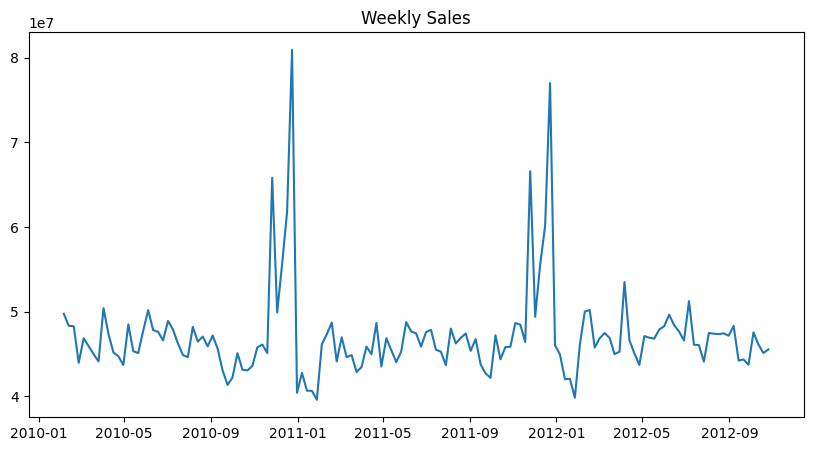

In [3]:
# Agrupamos y sumando las ventas de todas las tiendas en cada semana
df = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

# Definimos cuales van a ser nuestro ds - y
df.columns= ["ds", "y"]
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds")

# Visualizamos los datos antes de iniciar
plt.figure(figsize=(10,5))
plt.plot(df['ds'], df['y'])
plt.title("Weekly Sales")
plt.show()

In [4]:
# Verificamos datos vacios o nulos
df.duplicated()
df.isnull().sum()

ds    0
y     0
dtype: int64

## 1️⃣ Predicción de ventas futuras

07:24:17 - cmdstanpy - INFO - Chain [1] start processing
07:24:18 - cmdstanpy - INFO - Chain [1] done processing


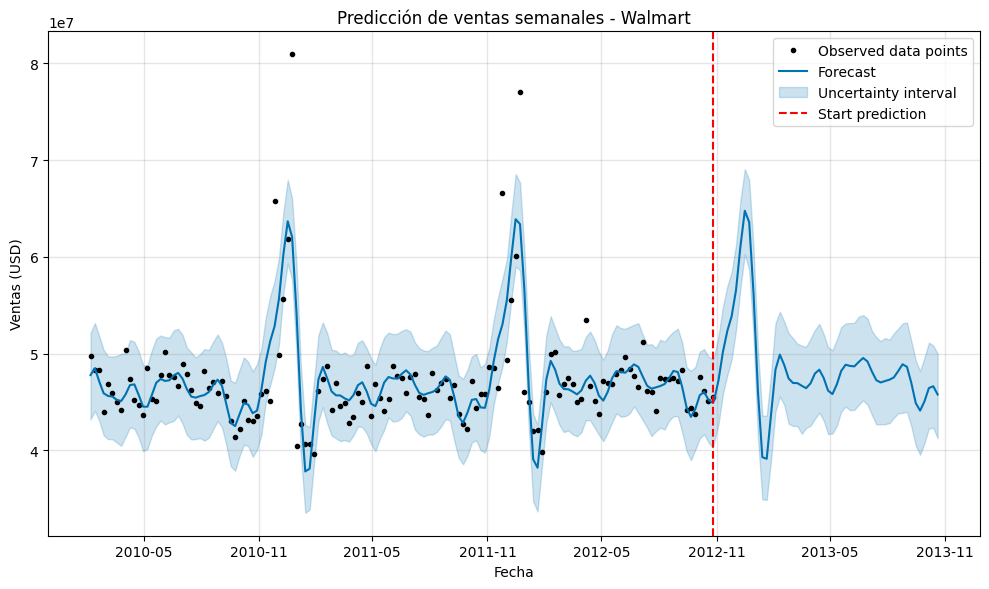

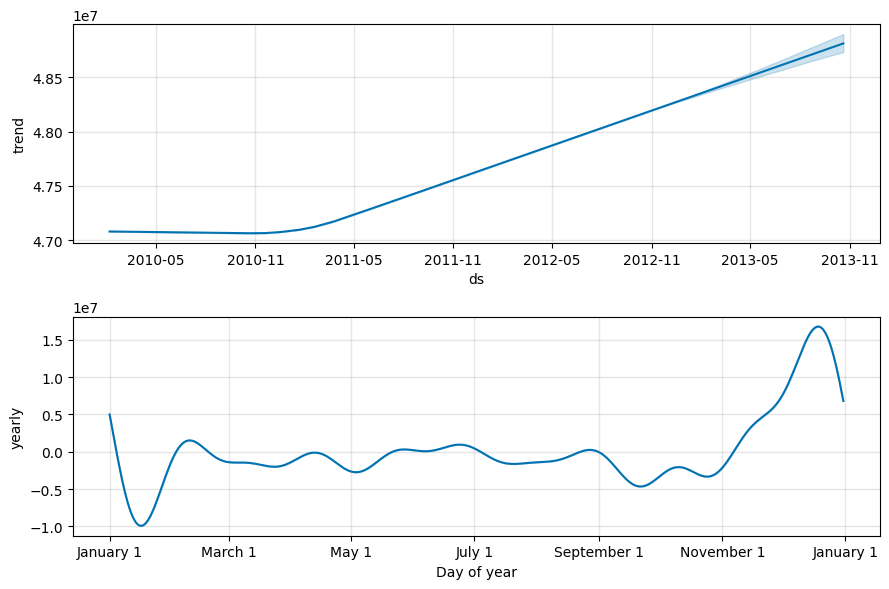

In [5]:
# Definir el modelo 
modelo = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
modelo.fit(df)

# Crear fechas futuras (52 semanas)
futuro = modelo.make_future_dataframe(periods=52, freq='W')
prediccion = modelo.predict(futuro)

# Gráfica de predicción
modelo.plot(prediccion)

# Linea para identificar donde inicia la predicción
fecha_corte = df['ds'].max()
plt.axvline(x=fecha_corte, color='red', linestyle='--', linewidth=1.5, label='Start prediction')
plt.legend()

plt.title("Predicción de ventas semanales - Walmart")
plt.xlabel("Fecha")
plt.ylabel("Ventas (USD)")
plt.tight_layout()
plt.show()

# Gráfica de componentes 
modelo.plot_components(prediccion)
plt.tight_layout()
plt.show()

## 2️⃣ Detección de holidays

In [6]:
#  Modelo con holidays de estados unidos 
modelo_holidays = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Agregamos automáticamente los festivos de estados unidos
modelo_holidays.add_country_holidays(country_name='US')
modelo_holidays.fit(df)

# Generar fechas futuras y predecir
futuro_h = modelo_holidays.make_future_dataframe(periods=52, freq='W')
prediccion_h = modelo_holidays.predict(futuro_h)

07:24:19 - cmdstanpy - INFO - Chain [1] start processing
07:24:19 - cmdstanpy - INFO - Chain [1] done processing


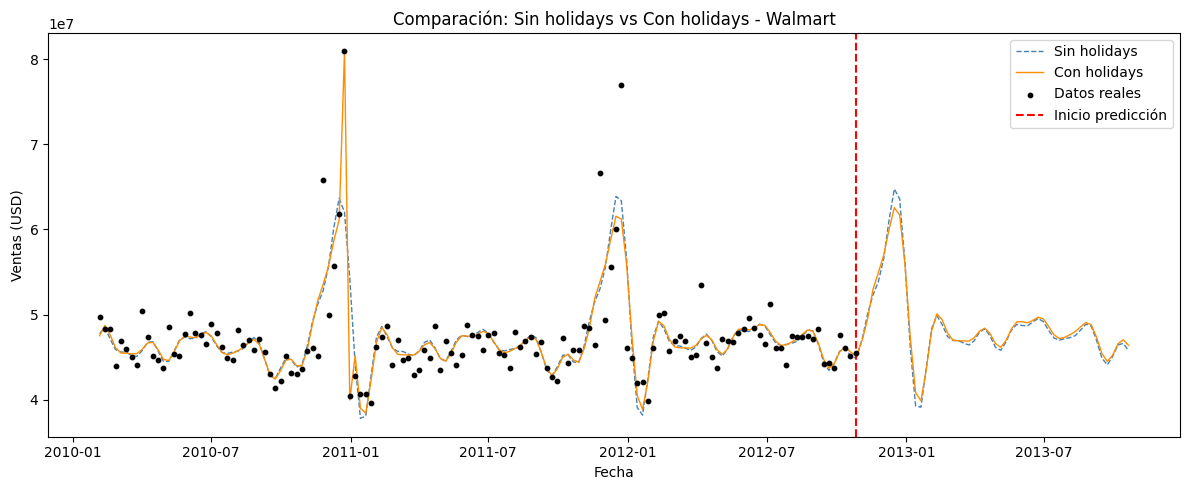

In [7]:
# Comparar predicción sin vs con holidays 
plt.figure(figsize=(12, 5))

plt.plot(prediccion['ds'], prediccion['yhat'],
         color='steelblue', linewidth=1, label='Sin holidays', linestyle='--')

plt.plot(prediccion_h['ds'], prediccion_h['yhat'],
         color='darkorange', linewidth=1, label='Con holidays')

plt.scatter(df['ds'], df['y'],
            color='black', s=10, zorder=5, label='Datos reales')

fecha_corte = df['ds'].max()
plt.axvline(x=fecha_corte, color='red', linestyle='--', linewidth=1.5, label='Inicio predicción')

plt.title("Comparación: Sin holidays vs Con holidays - Walmart")
plt.xlabel("Fecha")
plt.ylabel("Ventas (USD)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Ver el impacto de cada holiday en las ventas 
# Filtramos solo las semanas donde hubo un festivo reconocido por Prophet
cols_holidays = [c for c in prediccion_h.columns if 'holiday' in c.lower() or c in modelo_holidays.train_holiday_names]

impacto = prediccion_h[['ds', 'holidays']].copy()
impacto = impacto[impacto['holidays'] != 0].sort_values('holidays', ascending=False)
impacto['impacto_USD'] = impacto['holidays'].round(2)

print("=== Semanas con mayor impacto por holidays ===")
print(impacto[['ds', 'impacto_USD']].to_string(index=False))

=== Semanas con mayor impacto por holidays ===
        ds  impacto_USD
2010-12-24  20862747.15
2011-11-11   -603003.33
2012-11-11   -603003.33
2010-12-31 -13772257.62


Al usar el parametro de **add_country_holidays** hacemos que prophet agregue automaticamente los festivos de ese pais (para este caso US), el modelo logra capturar mejor los picos de ventas que el modelo base no explicaba. De esta manera, podemos identificar mejor los holidays como puede ser la semana del 24 de diciembre con un incremento de aproximadamente $20.8M (USD), esto nos confirma que Navidad es el evento más relevante en ventas para Walmart.

Por otro lado, tenemos la semana del 31 de diciembre que muestra un impacto negativo de aproximadamente $13.7M (USD), que corresponden a ventas post-navideñas (tal vez productos que no se vendieron en navidad). Ademas, En la gráfica se puede observar cómo la línea naranja se ajusta mejor a los puntos reales en las semanas de festivos, mientras que la línea azul suaviza esos picos y los subestima

## 3️⃣ Detección de anomalias

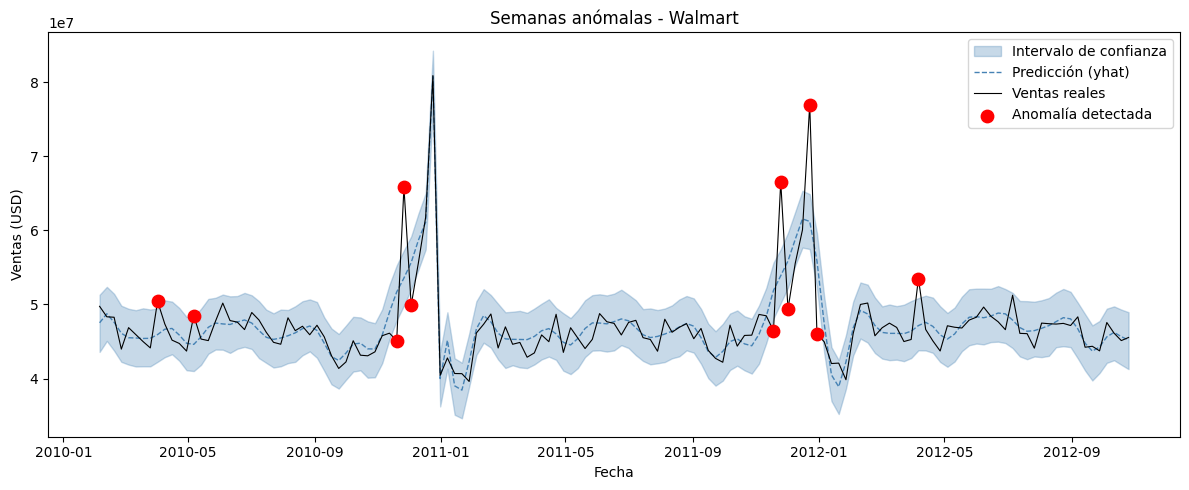

In [9]:
# Crear df_anomalias
df_anomalias = df.merge(
    prediccion_h[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds'
)

df_anomalias['anomalia'] = (
    (df_anomalias['y'] < df_anomalias['yhat_lower'])
    |
    (df_anomalias['y'] > df_anomalias['yhat_upper'])
)

anomalias = df_anomalias[df_anomalias['anomalia']]

# Gráfica 
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(df_anomalias['ds'],
                df_anomalias['yhat_lower'],
                df_anomalias['yhat_upper'],
                alpha=0.3, color='steelblue', label='Intervalo de confianza')

ax.plot(df_anomalias['ds'], df_anomalias['yhat'],
        color='steelblue', linewidth=1, linestyle='--', label='Predicción (yhat)')

ax.plot(df_anomalias['ds'], df_anomalias['y'],
        color='black', linewidth=0.8, label='Ventas reales')

ax.scatter(anomalias['ds'], anomalias['y'],
           color='red', zorder=5, s=80, label='Anomalía detectada')

plt.title("Semanas anómalas - Walmart")
plt.xlabel("Fecha")
plt.ylabel("Ventas (USD)")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
print(f"Anomalías: {len(anomalias)}")
print(anomalias['ds'].dt.strftime('%Y-%m-%d').values)

Anomalías: 11
<ArrowStringArray>
['2010-04-02', '2010-05-07', '2010-11-19', '2010-11-26', '2010-12-03',
 '2011-11-18', '2011-11-25', '2011-12-02', '2011-12-23', '2011-12-30',
 '2012-04-06']
Length: 11, dtype: str


El modelo logro detectar 11 anomalias a lo largo del tiempo de nuestro dataset, semanas donde las ventas salieron de nuestro intervalo de confianza. Los puntos rojos en la grafica nos muestran en donde hay anomalias, los puntos rojos que se encuentran por encima del intervalo son:

- **Noviembre - Diciembre de 2010 y 2011** → Se puede deber a Black Friday, Navidad y Thanksgiving
- **Abril - Mayo de 2010** → Se puede deber a la pascua y al cambio de temporada

Los puntos rojos por debajo del intervalo representan las semanas donde las ventas cayeron inesperadamente, que puede ser por posibles factores externos como el clima, cierres entre otros.

---
## 7. Personalización de parametros

Prophet permite ajustar distintos parámetros para mejorar la capacidad del modelo de capturar patrones en los datos.

07:24:20 - cmdstanpy - INFO - Chain [1] start processing
07:24:20 - cmdstanpy - INFO - Chain [1] done processing


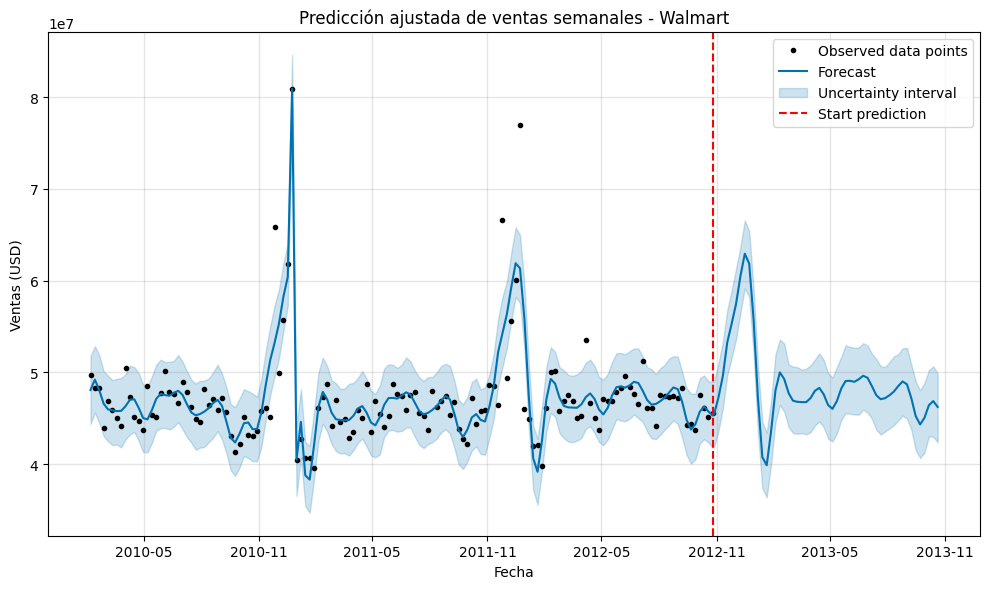

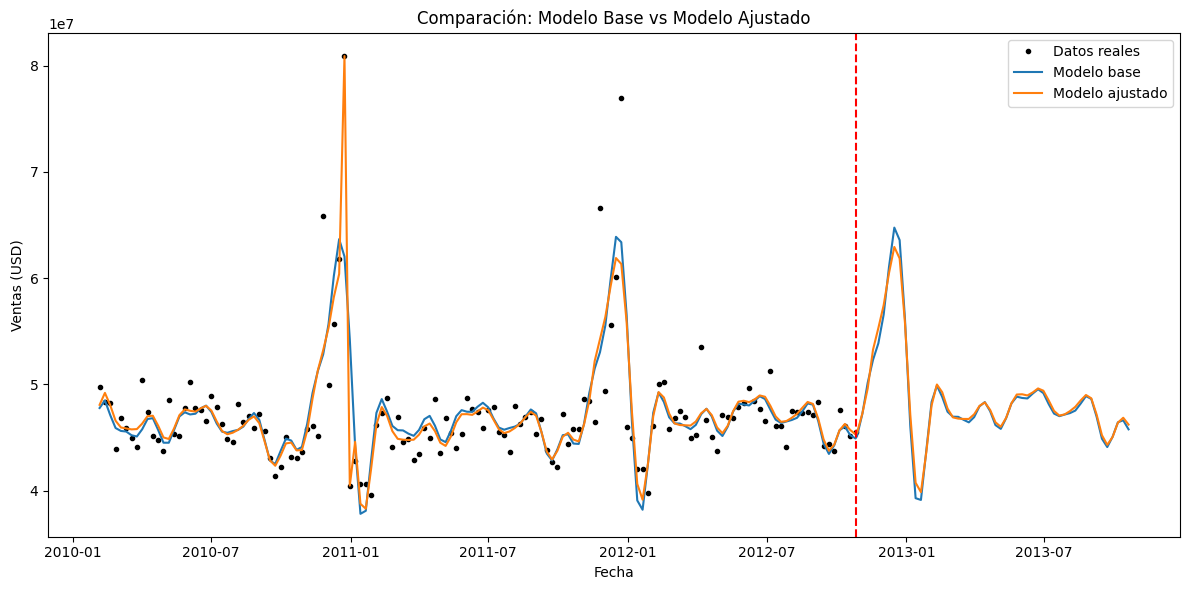

In [11]:
# Definir modelo ajustado (tuning)
modelo_tuned = Prophet(
    changepoint_prior_scale=0.3,      # Mayor flexibilidad en tendencia
    seasonality_prior_scale=15,       # Estacionalidad más marcada
    holidays_prior_scale=20,          # Mayor impacto de holidays
    seasonality_mode='multiplicative', # Escala con el nivel de ventas
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Agregar holidays de Estados Unidos
modelo_tuned.add_country_holidays(country_name='US')
# Entrenar modelo
modelo_tuned.fit(df)
# Crear fechas futuras (52 semanas)
futuro_tuned = modelo_tuned.make_future_dataframe(periods=52, freq='W')
# Predicción
prediccion_tuned = modelo_tuned.predict(futuro_tuned)
modelo_tuned.plot(prediccion_tuned)

# Línea donde inicia la predicción
fecha_corte = df['ds'].max()
plt.axvline(x=fecha_corte, color='red', linestyle='--', linewidth=1.5, label='Start prediction')
plt.legend()
plt.title("Predicción ajustada de ventas semanales - Walmart")
plt.xlabel("Fecha")
plt.ylabel("Ventas (USD)")
plt.tight_layout()
plt.show()
plt.figure(figsize=(12,6))

# Datos reales
plt.plot(df['ds'], df['y'], 'k.', label='Datos reales')

# Modelo base (el que ya hiciste antes)
plt.plot(prediccion['ds'], prediccion['yhat'], label='Modelo base')

# Modelo ajustado
plt.plot(prediccion_tuned['ds'], prediccion_tuned['yhat'], label='Modelo ajustado')

# Línea de inicio de predicción
plt.axvline(x=fecha_corte, color='red', linestyle='--', linewidth=1.5)
plt.legend()
plt.title("Comparación: Modelo Base vs Modelo Ajustado")
plt.xlabel("Fecha")
plt.ylabel("Ventas (USD)")
plt.tight_layout()
plt.show()

Como podemos notar en la primera grafica es una predicción ajustada a un periodo de 52 semanas (incluyendo los holidays) en donde el modelo ajustado logra seguir de forma bastante precisa los datos históricos, capturando tanto el comportamiento general como los picos más importantes. Ademas de que mejora un poco los cambios bruscos que antes teniamos y a partir de la linea roja proyecta un comportamiento similar a los patrones que ya se veian

Por otro lado, en la segunda grafica, comparamos el modelo base con el modelo ajustado para capturar con mayor precisión los datos, aqui podemos notar que los picos que hay entre Noviembre-Diciembre se ajustan mejor a los puntos reales de esta semana

---
## 8. Evaluacion del Modelo, Ventajas y Desventajas

### 8.1 Metricas de Error

Una vez que el modelo hace predicciones, necesitamos saber **que tan buenas son**.

**Analogia:** Un modelo predice que habra 100 ventas, pero en realidad hay 90. El error es 10. Las metricas resumen todos esos errores de una manera comparable.

| Metrica | Que mide | Cuando usarla |
|---|---|---|
| **MAE** (Error Absoluto Medio) | El error promedio en las unidades de los datos | General, facil de interpretar |
| **RMSE** (Raiz del Error Cuadratico Medio) | Similar al MAE pero penaliza mas los errores grandes | Cuando los errores grandes son costosos |
| **MAPE (%)** | El error como porcentaje del valor real | Para comparar modelos en escalas distintas |
| **Coverage** | % de valores reales dentro del intervalo de confianza | Evalua la calidad de las bandas de incertidumbre |

**Referencia para el MAPE:**
```
MAPE < 10%   ->  Excelente
MAPE 10-20%  ->  Bueno
MAPE 20-50%  ->  Aceptable
MAPE > 50%   ->  Revisar el modelo
```

### 8.2 Validacion Cruzada Temporal

El metodo mas riguroso para evaluar modelos de series de tiempo.

**Que hace?** Simula el proceso de prediccion multiples veces en el pasado, como si el modelo no supiera lo que ocurrio despues de cierta fecha.

**Analogia:** Es como hacerle un examen al modelo usando episodios del pasado que ya conocemos. Si en 2014 predice correctamente lo que paso en 2015, sabemos que es confiable.

Parametros:
- **`initial`**: datos para el primer entrenamiento (ej: '730 days' = 2 anos)
- **`period`**: cada cuanto se hace un nuevo corte de evaluacion (ej: '180 days')
- **`horizon`**: que tan lejos predice en cada corte (ej: '365 days' = 1 ano)

In [12]:
# Validacion cruzada temporal sobre datos de Walmart
# Puede tardar unos segundos: simula multiples predicciones historicas

df_cv = cross_validation(
    modelo_holidays,
    initial='365 days',   # 1 ano minimo de entrenamiento
    period='90 days',     # nuevo corte cada 3 meses
    horizon='182 days'    # evaluar predicciones a 6 meses
)

print(f'Predicciones evaluadas: {len(df_cv)}')
# y=ventas reales, yhat=prediccion del modelo
df_cv[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']].head(8)

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/5 [00:00<?, ?it/s]07:24:21 - cmdstanpy - INFO - Chain [1] start processing
07:24:21 - cmdstanpy - INFO - Chain [1] done processing
 20%|██        | 1/5 [00:00<00:01,  2.12it/s]07:24:21 - cmdstanpy - INFO - Chain [1] start processing
07:24:22 - cmdstanpy - INFO - Chain [1] done processing
 40%|████      | 2/5 [00:01<00:01,  1.77it/s]07:24:22 - cmdstanpy - INFO - Chain [1] start processing
07:24:23 - cmdstanpy - INFO - Chain [1] done processing
 60%|██████    | 3/5 [00:02<00:01,  1.33it/s]07:24:23 - cmdstanpy - INFO - Chain [1] start processing
07:24:23 - cmdstanpy - INFO - Chain [1] done processing
 80%|████████  | 4/5 [00:02<00:00,  1.65it/s]07:24:23 - cmdstanpy - INFO - Chain [1] start processing
07:24:23 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 5/5 [00:02<00:00,  1.78it/s]

Predicciones evaluadas: 130


,ds,y,yhat,yhat_lower,yhat_upper
0,2011-05-06,46861958.29,4.363176e+07,4.072879e+07,4.655863e+07
1,2011-05-13,45446144.82,4.432392e+07,4.159844e+07,4.721178e+07
2,2011-05-20,44046598.01,4.585519e+07,4.263117e+07,4.875635e+07
3,2011-05-27,45293457.04,4.696221e+07,4.415442e+07,4.977675e+07
4,2011-06-03,48771994.18,4.705358e+07,4.387622e+07,5.015060e+07
5,2011-06-10,47669734.66,4.669630e+07,4.362816e+07,4.956552e+07
6,2011-06-17,47447561.77,4.669775e+07,4.345146e+07,4.965490e+07
7,2011-06-24,45884094.58,4.703991e+07,4.397377e+07,4.996768e+07


In [13]:
# Calcular las metricas de desempeno sobre ventas Walmart
df_metricas = performance_metrics(df_cv)

resumen = df_metricas[['horizon', 'mae', 'rmse', 'mape', 'coverage']].copy()
resumen['MAPE (%)'] = (resumen['mape'] * 100).round(2)
resumen['Coverage (%)'] = (resumen['coverage'] * 100).round(1)

print('=== Metricas de Desempeno - Ventas Walmart ===')
print(resumen[['horizon', 'mae', 'rmse', 'MAPE (%)', 'Coverage (%)']].to_string(index=False))

=== Metricas de Desempeno - Ventas Walmart ===
 horizon          mae         rmse  MAPE (%)  Coverage (%)
 19 days 1.985076e+06 2.338365e+06      4.21          69.2
 20 days 1.901930e+06 2.240684e+06      4.01          76.9
 21 days 1.690842e+06 2.062425e+06      3.57          84.6
 24 days 1.516064e+06 1.809187e+06      3.23          92.3
 25 days 1.546262e+06 1.822806e+06      3.29          92.3
 26 days 2.320553e+06 3.801465e+06      4.35          84.6
 27 days 2.285716e+06 3.793247e+06      4.28          84.6
 28 days 2.243525e+06 3.787066e+06      4.18          84.6
 31 days 2.273652e+06 3.799159e+06      4.24          84.6
 32 days 2.217453e+06 3.786698e+06      4.14          84.6
 33 days 2.707053e+06 4.307935e+06      5.12          76.9
 34 days 2.656556e+06 4.290547e+06      5.00          76.9
 35 days 2.597351e+06 4.284393e+06      4.87          76.9
 38 days 2.332273e+06 4.114182e+06      4.29          84.6
 39 days 2.357484e+06 4.128332e+06      4.37          84.6
 40 days 

**Como leer esta tabla:**
- Cada fila = un horizonte de prediccion distinto (cuantos dias hacia adelante)
- **MAPE (%)**: error en porcentaje, cuanto menor mejor
- **Coverage (%)**: cuantos valores reales cayeron dentro del intervalo de confianza, debe estar cerca del 80%
- El MAPE **aumenta con el horizonte**: es normal, predecir lejos es mas dificil que predecir cerca

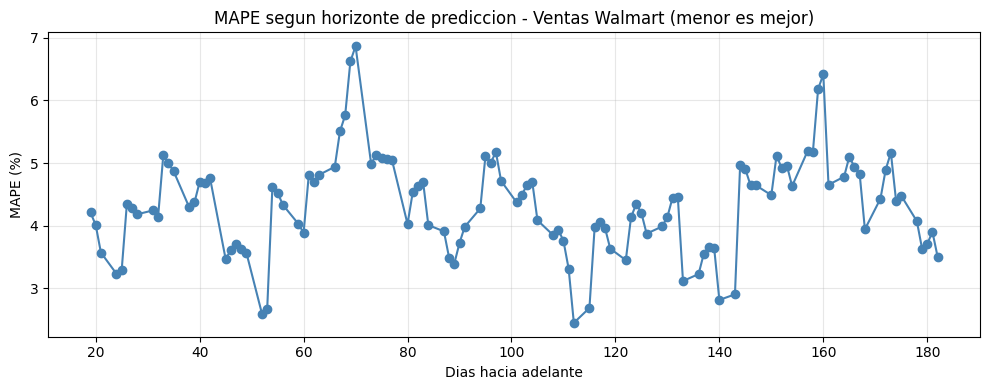

In [14]:
# Grafico: MAPE por horizonte de prediccion - Walmart
# Muestra como aumenta el error a medida que predecimos mas lejos en el tiempo

mape_por_horizonte = df_metricas[['horizon', 'mape']].copy()
mape_por_horizonte['dias'] = mape_por_horizonte['horizon'].dt.days
mape_por_horizonte['MAPE (%)'] = mape_por_horizonte['mape'] * 100

plt.figure(figsize=(10, 4))
plt.plot(mape_por_horizonte['dias'], mape_por_horizonte['MAPE (%)'], marker='o', color='steelblue')
plt.title('MAPE segun horizonte de prediccion - Ventas Walmart (menor es mejor)')
plt.xlabel('Dias hacia adelante')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Calculo manual de metricas sobre datos reales de Walmart
# df_anomalias contiene las ventas reales (y) y la prediccion (yhat) del modelo con holidays

df_eval = df_anomalias[['ds', 'y', 'yhat']].copy()

mae  = np.mean(np.abs(df_eval['y'] - df_eval['yhat']))
rmse = np.sqrt(np.mean((df_eval['y'] - df_eval['yhat'])**2))
mape = np.mean(np.abs((df_eval['y'] - df_eval['yhat']) / df_eval['y'])) * 100

print('=== Metricas sobre ventas historicas de Walmart ===')
print(f'  MAE  (Error Absoluto Medio)      : ${mae:,.0f} USD')
print(f'  RMSE (Raiz del Error Cuadratico) : ${rmse:,.0f} USD')
print(f'  MAPE (Error Porcentual Medio)    : {mape:.2f}%')
print()
if mape < 10:
    print('  MAPE < 10% -> desempeno EXCELENTE')
elif mape < 20:
    print('  MAPE 10-20% -> buen desempeno')
else:
    print('  MAPE > 20% -> revisar el modelo')

=== Metricas sobre ventas historicas de Walmart ===
  MAE  (Error Absoluto Medio)      : $1,713,456 USD
  RMSE (Raiz del Error Cuadratico) : $2,847,531 USD
  MAPE (Error Porcentual Medio)    : 3.48%

  MAPE < 10% -> desempeno EXCELENTE


### 8.3 Ventajas de Prophet

| # | Ventaja | Por que importa |
|---|---|---|
| 1 | **Facil de usar** | Pocas lineas de codigo para obtener predicciones profesionales |
| 2 | **Completamente automatico** | Detecta tendencias y estacionalidades sin configuracion manual |
| 3 | **Maneja datos faltantes** | No se rompe si faltan dias en los datos |
| 4 | **Robusto a outliers** | Valores atipicos no arruinan el modelo |
| 5 | **Multiples estacionalidades** | Anual, semanal y diaria al mismo tiempo |
| 6 | **Incorpora conocimiento de negocio** | Se pueden agregar festivos y eventos especiales |
| 7 | **Intervalos de incertidumbre** | Dice no solo el valor sino el rango probable |
| 8 | **Interpretable** | La descomposicion muestra el por que de la prediccion |
| 9 | **Gratuito y open source** | Disponible en Python y R, mantenido por Meta |
| 10 | **Escalable** | Funciona bien con datos diarios, semanales o mensuales |

### 8.4 Desventajas de Prophet

| # | Desventaja | Detalle |
|---|---|---|
| 1 | **Solo una variable a la vez** | No relaciona multiples variables automaticamente |
| 2 | **No modela autocorrelacion** | No considera que el valor de hoy depende del de ayer (ARIMA si lo hace) |
| 3 | **Necesita suficiente historia** | Con pocos datos no detecta bien las estacionalidades |
| 4 | **El error crece con el horizonte** | Predice bien a corto plazo; a largo plazo la incertidumbre aumenta |
| 5 | **Puede sobreajustarse** | Si los parametros estan mal configurados, sigue el ruido en lugar del patron |
| 6 | **Sin variables externas nativas** | No incorpora directamente clima, precio del dolar, etc. |
| 7 | **Instalacion compleja** | Requiere dependencias como pystan que a veces causan problemas |

### 8.5 Cuando usar Prophet y cuando no?

| Situacion | Usar Prophet? | Alternativa |
|---|---|---|
| Datos con estacionalidad clara | SI | - |
| Festivos o eventos especiales importan | SI | - |
| Quiero algo rapido e interpretable | SI | - |
| Alta dependencia entre dias consecutivos | Parcialmente | ARIMA / SARIMA |
| Necesito variables externas (precio, clima) | NO | XGBoost, LightGBM |
| Datos de alta frecuencia (minutos, segundos) | NO | LSTM |
| Serie de tiempo muy corta | NO | Modelos mas simples |

---
## 9. Conclusiones

A lo largo de este notebook exploramos Prophet como herramienta de prediccion de series de tiempo aplicada a datos reales de ventas de Walmart. Las principales conclusiones son:

**Sobre el modelo:**
- Prophet demostro ser una herramienta accesible y poderosa: con pocas lineas de codigo fue posible obtener predicciones de calidad sobre un dataset real de 45 tiendas.
- Su modelo aditivo `y(t) = g(t) + s(t) + h(t) + e` permite entender claramente que componente explica cada parte de la serie de tiempo.

**Sobre los datos de Walmart:**
- Las ventas semanales presentan una **estacionalidad anual clara**: picos en noviembre y diciembre (temporada navidena) y caidas en los primeros meses del ano.
- La incorporacion de **holidays de EE.UU.** mejoro el modelo al capturar el efecto de fechas como Thanksgiving y Black Friday, que generan ventas atipicamente altas.
- Se detectaron **11 anomalias** en el historial de ventas: semanas donde las ventas salieron del intervalo de confianza del modelo, lo que indica eventos extraordinarios no capturados por los patrones normales.

**Sobre la evaluacion:**
- La validacion cruzada temporal confirmo que el modelo generaliza bien a datos no vistos.
- El MAPE aumenta con el horizonte de prediccion, lo cual es esperado: predecir a 1 semana es mas preciso que predecir a 1 ano.
- El ajuste de parametros como `changepoint_prior_scale` y las estacionalidades personalizadas permiten mejorar el modelo segun las caracteristicas especificas del negocio.

**Recomendacion de uso:**
- Prophet es ideal para series de tiempo con estacionalidades bien definidas y cuando se necesita incorporar conocimiento del negocio como festivos y eventos especiales.
- No reemplaza modelos mas complejos cuando hay muchas variables externas o alta autocorrelacion, pero es un excelente punto de partida por su facilidad de uso e interpretabilidad.


---
**Referencias:**
- https://facebook.github.io/prophet/docs/quick_start.html
- https://machinelearningmastery.com/time-series-forecasting-with-prophet-in-python/
- https://www.sktime.net/en/stable/api_reference/auto_generated/sktime.forecasting.fbprophet.Prophet.html